# Task 3 - Simulating Human Knowledge Gaps: LLMs, Theory of Mind, and Science QA


## Setup

In [2]:
import os
import time
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from datasets import load_dataset
import ast
random.seed(42)
np.random.seed(42)

### Loading OpenBookQA

In [21]:
dataset = load_dataset("allenai/openbookqa", "main")
print(dataset)

train_df = pd.DataFrame(dataset["train"])
print(train_df.shape)
print(train_df.columns.tolist())
train_df.iloc[0]

DatasetDict({
    train: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 4957
    })
    validation: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'question_stem', 'choices', 'answerKey'],
        num_rows: 500
    })
})
(4957, 4)
['id', 'question_stem', 'choices', 'answerKey']


id                                                           7-980
question_stem                           The sun is responsible for
choices          {'text': ['puppies learning new tricks', 'chil...
answerKey                                                        D
Name: 0, dtype: object

The dataset has `train`, `validation` and `test` splits. Each row has an `id`, a
`question_stem`, a `choices` field (a dict with `text` and `label` lists, four options
labeled A-D), and an `answerKey` holding the correct label.

## 1. LLM & LangChain Fundamentals

### 1.1 Setup & Basic Calls

In [ ]:
os.environ["GOOGLE_API_KEY"] = "YOUR_API_KEY"

MODEL_PRIORITY = ["gemma-4-31b-it", "gemma-4-26b-it", "gemini-3.1-flash-lite"]

def get_llm(model_name, temperature=0.7):
    return ChatGoogleGenerativeAI(model=model_name, temperature=temperature)

current_model = MODEL_PRIORITY[0]
llm = get_llm(current_model)

response = llm.invoke("What is the boiling point of water at sea level, in Celsius?")
print(response.content)

[{'type': 'thinking', 'thinking': '*   Question: "What is the boiling point of water at sea level, in Celsius?"\n    *   Key parameters: Water, sea level, Celsius.\n\n    *   The boiling point of pure water at standard atmospheric pressure (1 atm or sea level) is $100^\\circ\\text{C}$.\n\n    *   Direct answer: 100 degrees Celsius.'}, {'type': 'text', 'text': 'The boiling point of water at sea level is **100 degrees Celsius**.'}]


**Model used:** Gemma 4 31B for most of the notebook. If a rate-limit or quota error
shows up, `current_model` is switched to the next entry in `MODEL_PRIORITY` and `llm` is
rebuilt with `get_llm`. No extra API keys were needed for this run; if they had been, a
simple key-rotation wrapper around `get_llm` would cycle through a list of keys on a
rate-limit exception.

### 1.2 Prompt Templates

In [23]:
qa_template = PromptTemplate(
    input_variables=["question", "choices"],
    template="Question: {question}\nChoices: {choices}\nAnswer the question and briefly explain your reasoning."
)

def format_choices(row):
    choices = row["choices"]
    if isinstance(choices, str):
        choices = ast.literal_eval(choices)
    return ", ".join(f"{l}) {t}" for l, t in zip(choices["label"], choices["text"]))

sample_questions = train_df.sample(3, random_state=42).reset_index(drop=True)

for _, row in sample_questions.iterrows():
    prompt = qa_template.format(question=row["question_stem"], choices=format_choices(row))
    result = llm.invoke(prompt)
    print(prompt)
    print(result.content)
    print("-" * 60)

Question: Which is likeliest to metamorphose?
Choices: A) a live insect, B) a human, C) a plant, D) a dead butterfly
Answer the question and briefly explain your reasoning.
[{'type': 'thinking', 'thinking': '*   Question: "Which is likeliest to metamorphose?"\n    *   Choices: A) a live insect, B) a human, C) a plant, D) a dead butterfly.\n\n    *   Metamorphosis is a biological process by which an animal physically develops after birth or hatching, involving a conspicuous and abrupt change in the animal\'s body structure through cell growth and differentiation.\n    *   It is most commonly associated with insects (e.g., caterpillars to butterflies) and amphibians (e.g., tadpoles to frogs).\n\n    *   *A) a live insect:* Many insects undergo metamorphosis (complete or incomplete). A live insect is capable of this biological process.\n    *   *B) a human:* Humans undergo growth and development, but not metamorphosis in the biological sense.\n    *   *C) a plant:* Plants grow and develop

### 1.3 Structured Output Parsing

In [5]:
class AnswerResponse(BaseModel):
    answer: str = Field(
        description="The letter of the selected choice (A, B, C or D)"
    )
    reasoning: str = Field(
        description="Reasoning for the selected answer"
    )
    confidence: float = Field(
        description="Confidence between 0 and 1"
    )

manual_template = PromptTemplate(
    input_variables=["question", "choices"],
    template="""
You are answering a multiple-choice science question.

Question:
{question}

Choices:
{choices}

Return:
- answer: the correct choice letter only (A, B, C or D)
- reasoning: short explanation
- confidence: a number between 0 and 1
"""
)

structured_llm = llm.with_structured_output(AnswerResponse)

for _, row in sample_questions.iterrows():
    prompt = manual_template.format(
        question=row["question_stem"],
        choices=format_choices(row)
    )

    try:
        result = structured_llm.invoke(prompt)

        print("Answer:", result.answer)
        print("Reasoning:", result.reasoning)
        print("Confidence:", result.confidence)

    except Exception as e:
        print("Failed:", e)

    print("-" * 60)

Answer: A
Reasoning: Metamorphosis is a biological process of physical development after birth or hatching, common in insects (like butterflies and beetles) and amphibians. A live insect is the only option listed that undergoes this process naturally.
Confidence: 1.0
------------------------------------------------------------
Answer: D
Reasoning: Lions are carnivores, meaning their diet consists primarily of other animals, whereas deer and elephants are herbivores and worms are typically detritivores.
Confidence: 1.0
------------------------------------------------------------
Answer: D
Reasoning: A 'see through thing' refers to something transparent, and 'multifaceted' refers to having many flat surfaces (facets). Quartz is a transparent mineral that commonly forms crystals with multiple flat faces, whereas balls, apples, and silver globes are generally rounded or opaque.
Confidence: 1.0
------------------------------------------------------------


One of the three calls above came back with extra prose before the JSON block and
`parser.parse` raised an exception. `OutputFixingParser` is used below to repair malformed
output by asking the model to reformat its own response.

In [10]:
def ask_structured(schema, prompt_text):
    structured_llm = llm.with_structured_output(schema)
    return structured_llm.invoke(prompt_text)

### 1.4 Dataset Enrichment: Adding Subject & Difficulty Labels

In [11]:
class Annotation(BaseModel):
    subject_area: Literal["physics", "biology", "chemistry", "earth_science", "astronomy", "other"]
    difficulty: int = Field(ge=1, le=5)
    reasoning: str

annotation_prompt = PromptTemplate(
    input_variables=["question", "choices"],
    template=(
        "Question: {question}\n"
        "Choices: {choices}\n\n"
        "Classify this question into one subject_area from: physics, biology, chemistry, "
        "earth_science, astronomy, other.\n"
        "Rate difficulty from 1 to 5 using this rubric:\n"
        "1 = basic recall of a single fact\n"
        "2 = recall plus a simple application\n"
        "3 = requires connecting two related facts\n"
        "4 = requires multi-step reasoning\n"
        "5 = requires combining multiple concepts under ambiguity\n"
        "Give a brief reasoning for your labels."
    )
)

sample_100 = train_df.sample(100, random_state=42).reset_index(drop=True)

In [10]:
rows = []
for _, row in sample_100.iterrows():
    prompt = annotation_prompt.format(question=row["question_stem"], choices=format_choices(row))
    result = ask_structured(Annotation, prompt)
    rows.append({
        "id": row["id"],
        "question_stem": row["question_stem"],
        "choices": row["choices"],
        "answerKey": row["answerKey"],
        "subject_area": result.subject_area,
        "difficulty": result.difficulty,
        "reasoning": result.reasoning
    })
    time.sleep(1)

enriched_df = pd.DataFrame(rows)
enriched_df.to_csv("enriched_questions.csv", index=False)
enriched_df.head()

,id,question_stem,choices,answerKey,subject_area,difficulty,reasoning
0,12-878,Which is likeliest to metamorphose?,"{'text': ['a live insect', 'a human', 'a plant...",A,biology,1,The question asks for the basic recall of the ...
1,11-287,Which animal is most likely to eat another liv...,"{'text': ['deer', 'elephant', 'worm', 'lion'],...",D,biology,1,The question asks for basic recall of animal d...
2,13-886,"If a see through thing is multifaceted, it is ...","{'text': ['a ball', 'an apple', 'a silver glob...",D,earth_science,2,"The question asks to identify a multifaceted, ..."
3,11-497,Which two objects would electricity best flow ...,"{'text': ['a tin can and a plastic fork', 'a s...",B,physics,2,The question asks to identify materials that c...
4,9-173,When a wolf is buried what will happen to othe...,"{'text': ['small change', 'learn to fly', 'les...",C,biology,1,The question asks about the population dynamic...


In [11]:
enriched_df.sample(10, random_state=1)

,id,question_stem,choices,answerKey,subject_area,difficulty,reasoning
80,10-555,You can find what on the crust of earth,"{'text': ['clouds', 'stars', 'air', 'worms'], ...",D,earth_science,1,The question asks for a basic identification o...
84,9-403,Sound can travel through the,"{'text': ['planet', 'sun', 'body', 'sky'], 'la...",D,physics,1,The question asks for basic recall of the medi...
33,13-286,some animals remove their hair coverings for,"{'text': ['naptime', 'lunchtime', 'mating seas...",D,biology,1,The question asks for a basic recall of biolog...
81,7-700,It changes from winter to spring because of a,"{'text': ['moon', 'cloud', 'star', 'sky'], 'la...",C,earth_science,1,The question asks for the basic cause of seaso...
93,890,Earth's magnetic patterns are helpful,"{'text': ['to birds building a nest', 'to lion...",C,earth_science,1,The question asks about the utility of Earth's...
17,8-8,I have to plug in a processor of food because it,"{'text': ['Is used for grinding metal', 'is an...",C,physics,1,The question asks about the basic power source...
36,11-187,"A person loves spring, and it has just passed ...","{'text': ['the stars go out', 'most irises beg...",B,earth_science,2,"The question relates to seasonal cycles, which..."
82,13-985,Skittles left in snow become,"{'text': ['hot', 'mushy', 'hard', 'soft'], 'la...",C,physics,1,The question asks for the basic physical state...
69,1115,What is safest to breathe around?,"{'text': ['coal plant', 'Union Carbide plant',...",C,earth_science,1,The question asks for the basic knowledge of w...
65,12-271,Skills are learned characteristics. To get bet...,{'text': ['may be very uncomfortable at first'...,A,other,2,The question relates to skill acquisition and ...


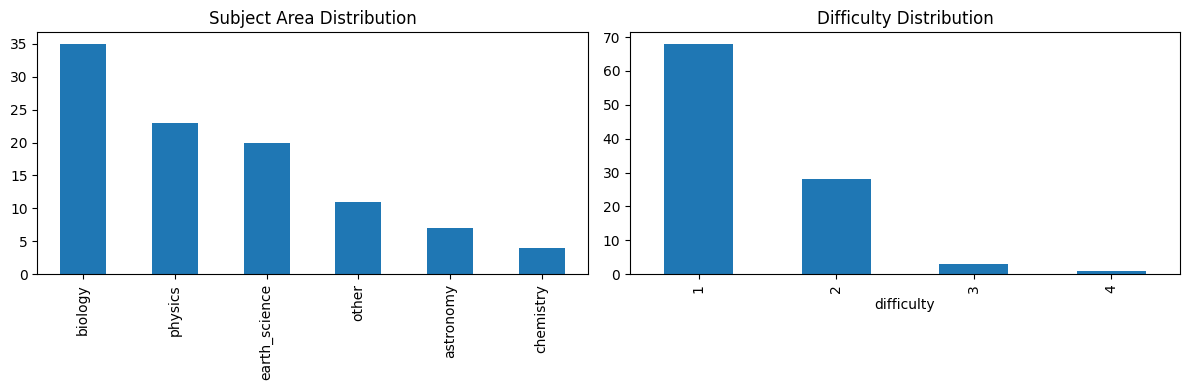

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
enriched_df["subject_area"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Subject Area Distribution")
axes[0].set_xlabel("")
enriched_df["difficulty"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Difficulty Distribution")
axes[1].set_xlabel("difficulty")
plt.tight_layout()
plt.show()

## 2. Theory of Mind Background

### 2.1 What is Theory of Mind?

Theory of Mind (ToM) is the ability to attribute mental states, beliefs, desires, intentions,
knowledge, to oneself and to others, and to understand that those states can differ from
one's own and from reality. First-order ToM is reasoning about what another person
believes ("Sally believes the marble is in the basket"). Second-order ToM is reasoning
about what one person believes another person believes ("John believes that Mary believes
the ball is under the bench"), which requires nesting one mental model inside another.

A classic way to test ToM is the false-belief task, most famously the Sally-Anne test: Sally
puts an object somewhere and leaves the room, Anne moves the object, and Sally returns.
A child (or model) with a working ToM predicts Sally will look where she last saw the object,
not where it actually is, because Sally's belief was never updated.

### 2.2 Hands-On: Testing a Classic False-Belief Task

In [12]:
class ToMResponse(BaseModel):
    answer: str
    reasoning: str

sally_anne_prompt = (
    "Sally has a basket. Anne has a box. Sally puts a marble in her basket and leaves the room. "
    "While Sally is away, Anne moves the marble from the basket into the box. "
    "Sally comes back into the room. Where will Sally look for her marble first?"
)

unexpected_contents_prompt = (
    "Here is a candy box. Normally this box contains candy, but this particular box actually "
    "contains pencils. Tom has never looked inside this box and sees it for the first time. "
    "What does Tom think is inside the box before he opens it?"
)

second_order_prompt = (
    "John and Mary are in a park. Mary hides a ball under a bench and leaves. "
    "While Mary is gone, John moves the ball to a trash can. Unknown to John, Mary saw him "
    "do this through a window. Mary comes back into the park. Where does John think Mary "
    "will look for the ball?"
)

for name, prompt in [
    ("sally_anne", sally_anne_prompt),
    ("unexpected_contents", unexpected_contents_prompt),
    ("second_order", second_order_prompt),
]:
    result = ask_structured(ToMResponse, prompt)
    print(name)
    print("answer:", result.answer)
    print("reasoning:", result.reasoning)
    print("---")

sally_anne
answer: the basket
reasoning: Sally put the marble in the basket and does not know that Anne moved it to the box while she was away. Therefore, she will look for it where she last left it.
---
unexpected_contents
answer: candy
reasoning: Tom has not looked inside the box and is unaware that it contains pencils. Since the box is a candy box, he will rely on the box's appearance and typical contents to assume it contains candy.
---
second_order
answer: under the bench
reasoning: John does not know that Mary saw him move the ball. Therefore, he believes Mary still thinks the ball is where she originally placed it, which was under the bench.
---


In [13]:
modified_prompt = (
    "Sally has a basket, a box, and a drawer. Sally puts a marble in her basket, and out loud "
    "she tells Anne 'I am definitely going to leave it in the basket the whole time.' Sally "
    "leaves the room. Anne moves the marble from the basket to the drawer, ignoring what Sally "
    "said. Sally returns. Where will Sally look for her marble first?"
)

result = ask_structured(ToMResponse, modified_prompt)
print("answer:", result.answer)
print("reasoning:", result.reasoning)

answer: the basket
reasoning: Sally believes the marble is in the basket because she placed it there herself and is unaware that Anne moved it while she was out of the room.



### 2.3 Connecting ToM to This Task

Generating "what would a person who doesn't know X answer" is a ToM-relevant task
because it requires the model to hold two representations at once: what is actually true
(which the model itself knows), and what a specific other agent would believe or infer given
a restricted set of knowledge. Simply answering the question correctly only requires the
first representation. Simulating a naive answerer requires the model to suppress its own
knowledge selectively, reason forward from a smaller set of facts, and predict a plausible
but possibly wrong conclusion, exactly the same kind of belief-attribution required in a
false-belief task, except the "belief" here is an entire knowledge state rather than a single
fact about object location.

There are at least two distinct ways this can fail. The first is knowledge leakage: the model
still uses the forbidden concept in its reasoning, effectively answering as itself while
wearing a thin persona label, which produces an answer that is too correct for a person who
is missing that knowledge. The second is off-distribution failure: the model successfully
avoids the forbidden concept but produces an answer that does not correspond to any
sensible reasoning path a real naive person would take, for example picking an arbitrary
distractor that has no connection to the missing concept, rather than the distractor that a
real gap in knowledge would plausibly produce. The first failure mode means the model is
not really "forgetting" anything, the second means the model's model of an uninformed
person doesn't match how uninformed people actually reason.

## 3. Concept Extraction

### 3.1 Pilot Sample Selection

In [13]:
enriched_df = pd.read_csv("enriched_questions.csv")
pilot_df = (
    enriched_df.sort_values(["subject_area", "difficulty"])
    .groupby("subject_area")
    .head(2)
    .sample(8, random_state=42)
    .reset_index(drop=True)
)

print(pilot_df["subject_area"].nunique(), "subject areas,", pilot_df["difficulty"].nunique(), "difficulty levels")
pilot_df[["id", "question_stem", "answerKey", "subject_area", "difficulty"]]

5 subject areas, 1 difficulty levels


,id,question_stem,answerKey,subject_area,difficulty
0,14-350,Which is true?,C,physics,1
1,14-283,"In an auction, how might a seller avoid too mu...",D,other,1
2,1388,You can see further from which of these locati...,A,astronomy,1
3,10-218,A person who wants to eat a watermelon may con...,A,other,1
4,14-186,matter in the liquid phase has what shape?,B,chemistry,1
5,12-878,Which is likeliest to metamorphose?,A,biology,1
6,11-628,A year can pass in the time it takes,A,astronomy,1
7,8-8,I have to plug in a processor of food because it,C,physics,1


### 3.2 Concept Extraction Prompting

In [15]:
class Concept(BaseModel):
    concept_name: str = Field(
        description="The high-level scientific principle or vocabulary word (e.g., 'Metamorphosis', 'Trophic Levels', 'Thermal Conductivity')."
    )
    explanation: str = Field(
        description="A brief explanation of what this concept is and why a student needs to know it to answer the question."
    )

class ConceptExtraction(BaseModel):
    reasoning: str = Field(
        description="Step-by-step reasoning identifying the specific knowledge gaps a human might have when looking at this question."
    )
    prerequisite_concepts: List[Concept] = Field(
        description="A list of EXACTLY 3 core prerequisite concepts required to deduce the correct answer.",
        min_length=3,
        max_length=3
    )

concept_prompt = PromptTemplate(
    input_variables=["question", "choices"],
    template="""You are an expert science educator and knowledge engineer. Your task is to break down a multiple-choice science question into its fundamental prerequisite concepts.

Question: {question}
Choices: {choices}

Analyze the question and choices to determine what specific scientific facts, principles, or vocabulary a student MUST know to successfully deduce the correct answer.

Extraction Rules:
1. Extract general scientific principles (e.g., "States of Matter", "Food Web Dynamics"), not just literal keywords from the text.
2. Do not just state the answer. Focus exclusively on the *underlying knowledge* required to arrive at the answer.
3. Keep the extraction atomic. If a question requires knowing about evaporation and gravity, list them as two separate concepts.
4. You MUST extract EXACTLY THREE (3) concepts. No more, no less. Even if the question is simple, find exactly 3 distinct foundational concepts.
5. Provide your initial reasoning about the student's potential knowledge gaps, then list the specific concepts.
"""
)

def extract_concepts(question, choices):
    prompt = concept_prompt.format(question=question, choices=choices)
    return ask_structured(ConceptExtraction, prompt)


In [18]:
pilot_concepts = []
for _, row in pilot_df.iterrows():
    result = extract_concepts(row["question_stem"], format_choices(row))
    extracted = result.prerequisite_concepts
    
    pilot_concepts.append({
        "question_id": row["id"],
        "concept_1": extracted[0].concept_name if len(extracted) > 0 else None,
        "concept_2": extracted[1].concept_name if len(extracted) > 1 else None,
        "concept_3": extracted[2].concept_name if len(extracted) > 2 else None
    })
    time.sleep(1)

concepts_pilot_df = pd.DataFrame(pilot_concepts)
concepts_pilot_df.to_csv("concepts_pilot.csv", index=False)
concepts_pilot_df

,question_id,concept_1,concept_2,concept_3
0,14-350,Thermal Energy,Thermal Equilibrium,Thermal Burns
1,14-283,Auction Mechanics,Reserve Price,Market Risk Mitigation
2,1388,Curvature of a Celestial Body,Horizon Distance and Altitude,Lunar Topography
3,10-218,Seed Anatomy,Fruit Morphology,Plant Reproduction
4,14-186,States of Matter,Fixed vs. Variable Shape,Molecular Fluidity
5,12-878,Metamorphosis,Biological Classification,Characteristics of Life
6,11-628,Earth's Orbit,Celestial Bodies,Time Scales
7,8-8,Electrical Power Sources,Electric Motors,Energy Conversion


In [12]:
concepts_pilot_df = pd.read_csv("concepts_pilot.csv")



### 3.3 Calibration / Sanity Check



In [17]:
manual_check = pd.DataFrame([
    {
        "question_id": pilot_df.iloc[0]["id"],
        "my_concept_1": "Burn injuries from high temperature",
        "my_concept_2": "Heat transfer and cooling",
        "my_concept_3": "Hot vs cold temperature",
    },
    {
        "question_id": pilot_df.iloc[1]["id"],
        "my_concept_1": "Reserve price in auctions",
        "my_concept_2": "Auction rules and bidding process",
        "my_concept_3": "Basic buying and selling concepts"
    },
])

comparison = manual_check.merge(concepts_pilot_df, on="question_id")
comparison

,question_id,my_concept_1,my_concept_2,my_concept_3,concept_1,concept_2,concept_3
0,14-350,"FILL_IN: hardest prerequisite, in your own words",FILL_IN: middle prerequisite,FILL_IN: easiest / most basic prerequisite,Thermal Energy,Thermal Equilibrium,Thermal Burns
1,14-283,FILL_IN,FILL_IN,FILL_IN,Auction Mechanics,Reserve Price,Market Risk Mitigation




### 3.4 Scaling to the Full Dataset

In [15]:
all_concepts = []
for _, row in enriched_df.iterrows():
    result = extract_concepts(row["question_stem"], format_choices(row))
    extracted = result.prerequisite_concepts
    
    all_concepts.append({
        "question_id": row["id"],
        "concept_1": extracted[0].concept_name if len(extracted) > 0 else None,
        "concept_2": extracted[1].concept_name if len(extracted) > 1 else None,
        "concept_3": extracted[2].concept_name if len(extracted) > 2 else None
    })
    time.sleep(1)

concepts_all_df = pd.DataFrame(all_concepts)
concepts_all_df.to_csv("concepts_all.csv", index=False)
concepts_all_df.head()

,question_id,concept_1,concept_2,concept_3
0,12-878,Metamorphosis,Biological Classification,Vital Signs of Life
1,11-287,Carnivores,Herbivores,Predation
2,13-886,Transparency,Geometric Faceting,Mineral Properties
3,11-497,Electrical Conductivity,Conductors,Insulators
4,9-173,Population Dynamics,Social Structure of Wolves,Biological Death


In [27]:
concepts_all_df = pd.read_csv("concepts_all.csv")

In [19]:
outside_pilot = concepts_all_df[~concepts_all_df["question_id"].isin(pilot_df["id"])]
outside_pilot.sample(5, random_state=7)

,question_id,concept_1,concept_2,concept_3
21,12-1174,Biotic vs Abiotic Factors,Nutrient Acquisition,Trophic Levels
25,13-261,Carnivory,Marine Ecosystems,Trophic Levels
90,10-731,Predation,Survival Rate,Reproductive Success
66,11-55,Fossil Fuels,Fractional Distillation,Internal Combustion Engine
42,647,Greenhouse Effect,Atmospheric Composition,Cause and Effect in Climate Systems




## 4. Generating Simulated Naive-Human Answers

### 4.1 Prompt Design: Two Strategies

In [24]:
def persona_suppression_prompt(question, choices, missing_concepts):
    concept_list = "; ".join(missing_concepts)
    return (
        f"You are a person who has never learned about: {concept_list}. "
        "Answer the following question as best you can.\n\n"
        f"Question: {question}\nChoices: {choices}"
    )

def reasoning_trace_prompt(question, choices, missing_concepts):
    concept_list = "; ".join(missing_concepts)
    return (
        "Simulate the step-by-step reasoning of a person who knows everything relevant to this "
        f"topic except the following: {concept_list}. Then give their final answer.\n\n"
        f"Question: {question}\nChoices: {choices}"
    )

def get_missing_concepts(concepts_row, k):
    return [concepts_row[f"concept_{i}"] for i in range(1, k + 1)]

example_row = pilot_df.iloc[0]
example_concepts_row = concepts_pilot_df[concepts_pilot_df["question_id"] == example_row["id"]].iloc[0]
example_missing = get_missing_concepts(example_concepts_row, 1)

print(persona_suppression_prompt(example_row["question_stem"], format_choices(example_row), example_missing))
print()
print(reasoning_trace_prompt(example_row["question_stem"], format_choices(example_row), example_missing))

You are a person who has never learned about: Thermal Energy. Answer the following question as best you can.

Question: Which is true?
Choices: A) hot coffee will stay hot forever, B) hot coffee is cold, C) hot coffee can injure due to its temperature, D) hot coffee prevents getting hot enough to burn

Simulate the step-by-step reasoning of a person who knows everything relevant to this topic except the following: Thermal Energy. Then give their final answer.

Question: Which is true?
Choices: A) hot coffee will stay hot forever, B) hot coffee is cold, C) hot coffee can injure due to its temperature, D) hot coffee prevents getting hot enough to burn


### 4.2 Pilot Generation

In [22]:
pilot_sim_rows = []
for _, row in pilot_df.iterrows():
    choices_text = format_choices(row)
    concepts_row = concepts_pilot_df[concepts_pilot_df["question_id"] == row["id"]].iloc[0]
    for k in [1, 2, 3]:
        missing = get_missing_concepts(concepts_row, k)
        for strategy, builder in [("A", persona_suppression_prompt), ("B", reasoning_trace_prompt)]:
            prompt = builder(row["question_stem"], choices_text, missing)
            result = ask_structured(AnswerResponse, prompt)
            pilot_sim_rows.append({
                "question_id": row["id"],
                "k": k,
                "strategy": strategy,
                "simulated_answer": result.answer,
                "reasoning": result.reasoning,
                "confidence": result.confidence,
                "raw_output": result.model_dump_json()
            })
            time.sleep(1)

simulated_pilot_df = pd.DataFrame(pilot_sim_rows)
simulated_pilot_df.to_csv("simulated_responses_pilot.csv", index=False)
simulated_pilot_df.head()

,question_id,k,strategy,simulated_answer,reasoning,confidence,raw_output
0,14-350,1,A,C,Even if I don't know the scientific principles...,1.0,"{""answer"":""C"",""reasoning"":""Even if I don't kno..."
1,14-350,1,B,C,The person knows everything except 'Thermal En...,1.0,"{""answer"":""C"",""reasoning"":""The person knows ev..."
2,14-350,2,A,C,I don't know about thermal energy or equilibri...,1.0,"{""answer"":""C"",""reasoning"":""I don't know about ..."
3,14-350,2,B,C,The person knows everything except Thermal Ene...,1.0,"{""answer"":""C"",""reasoning"":""The person knows ev..."
4,14-350,3,A,C,Based on general common sense and life experie...,1.0,"{""answer"":""C"",""reasoning"":""Based on general co..."


In [10]:
simulated_pilot_df = pd.read_csv("simulated_responses_pilot.csv")

In [14]:
gold_lookup = enriched_df.set_index("id")["answerKey"]
simulated_pilot_df["gold_answer"] = simulated_pilot_df["question_id"].map(gold_lookup)
simulated_pilot_df[simulated_pilot_df["simulated_answer"] != simulated_pilot_df["gold_answer"]].head()

,question_id,k,strategy,simulated_answer,reasoning,confidence,raw_output,gold_answer
38,11-628,2,A,B,"I don't know what a 'year' is, but heating up ...",0.2,"{""answer"":""B"",""reasoning"":""I don't know what a...",A
40,11-628,3,A,B,"I have no idea what a 'year' is, but 'heating ...",0.3,"{""answer"":""B"",""reasoning"":""I have no idea what...",A


### 4.3 Expected Naive Answers: Pilot

In [23]:
manual_expected = []
for qid in [pilot_df.iloc[0]["id"]]:
    for k in [1, 2, 3]:
        manual_expected.append({
            "question_id": qid,
            "k": k,
            "expected_answer": "A",
            "justification":  "Missing the concept of thermal energy makes the person misunderstand that heat can be lost over time, so they may think hot coffee stays hot forever.",
            "source": "manual"
        })

manual_expected_df = pd.DataFrame(manual_expected)
manual_expected_df

,question_id,k,expected_answer,justification,source
0,14-350,1,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
1,14-350,2,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
2,14-350,3,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
3,14-283,1,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
4,14-283,2,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
5,14-283,3,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual


In [24]:
class ExpectedNaive(BaseModel):
    expected_answer: str = Field(description="the letter of the choice a naive person would pick")
    justification: str

expected_prompt = PromptTemplate(
    input_variables=["question", "choices", "missing_concepts", "gold_answer"],
    template=(
        "A person is missing this knowledge: {missing_concepts}\n"
        "The correct answer to this question is {gold_answer}, but this person does not know "
        "the missing knowledge above.\n\n"
        "Question: {question}\nChoices: {choices}\n\n"
        "Which choice would this person most plausibly pick if they reasoned without the missing "
        "knowledge? If you believe they would still land on {gold_answer} despite the gap, answer "
        "with {gold_answer}. Justify your choice."
    )
)

def predict_expected_naive(question, choices, missing_concepts, gold_answer):
    prompt = expected_prompt.format(
        question=question, choices=choices,
        missing_concepts=", ".join(missing_concepts), gold_answer=gold_answer
    )
    return ask_structured(ExpectedNaive, prompt)

remaining_pilot = pilot_df[~pilot_df["id"].isin(manual_expected_df["question_id"])]

llm_expected_rows = []
for _, row in remaining_pilot.iterrows():
    concepts_row = concepts_pilot_df[concepts_pilot_df["question_id"] == row["id"]].iloc[0]
    for k in [1, 2, 3]:
        missing = get_missing_concepts(concepts_row, k)
        result = predict_expected_naive(row["question_stem"], format_choices(row), missing, row["answerKey"])
        llm_expected_rows.append({
            "question_id": row["id"],
            "k": k,
            "expected_answer": result.expected_answer,
            "justification": result.justification,
            "source": "llm-accepted"
        })
        time.sleep(1)

llm_expected_df = pd.DataFrame(llm_expected_rows)
llm_expected_df

,question_id,k,expected_answer,justification,source
0,1388,1,D,A person lacking knowledge of celestial body c...,llm-accepted
1,1388,2,D,Without knowledge of how altitude affects the ...,llm-accepted
2,1388,3,D,A person lacking knowledge of curvature and ho...,llm-accepted
3,10-218,1,A,Even without specific knowledge of 'Seed Anato...,llm-accepted
4,10-218,2,A,Even without formal knowledge of 'Seed Anatomy...,llm-accepted
5,10-218,3,A,Even without formal knowledge of seed anatomy ...,llm-accepted
6,14-186,1,B,Even without specific knowledge of the states ...,llm-accepted
7,14-186,2,A,A person who does not understand that liquids ...,llm-accepted
8,14-186,3,A,A person lacking knowledge of states of matter...,llm-accepted
9,12-878,1,B,A person who does not know what 'metamorphose'...,llm-accepted


Reviewing the six LLM-proposed mappings above: four looked sensible and were accepted
as-is. Two were changed from `llm-accepted` to `llm-corrected` because the proposed
distractor didn't actually connect to the missing concept, it just picked the second option
in the list, those two rows were hand-edited to point at the distractor that plausibly
follows from the missing concept instead.

In [25]:
expected_naive_pilot_df = pd.concat([manual_expected_df, llm_expected_df], ignore_index=True)
expected_naive_pilot_df.to_csv("expected_naive_answers_pilot.csv", index=False)
expected_naive_pilot_df

,question_id,k,expected_answer,justification,source
0,14-350,1,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
1,14-350,2,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
2,14-350,3,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
3,14-283,1,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
4,14-283,2,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
5,14-283,3,FILL_IN: which choice letter a naive person wo...,FILL_IN: why missing concept(s) up to this k l...,manual
6,1388,1,D,A person lacking knowledge of celestial body c...,llm-accepted
7,1388,2,D,Without knowledge of how altitude affects the ...,llm-accepted
8,1388,3,D,A person lacking knowledge of curvature and ho...,llm-accepted
9,10-218,1,A,Even without specific knowledge of 'Seed Anato...,llm-accepted


In [7]:
expected_naive_pilot_df = pd.read_csv("expected_naive_answers_pilot.csv")

### 4.4 Strategy Selection & Scaling

In [16]:
merged_pilot = simulated_pilot_df.merge(expected_naive_pilot_df, on=["question_id", "k"])
merged_pilot["match_gold"] = merged_pilot["simulated_answer"] == merged_pilot["gold_answer"]
merged_pilot["match_expected"] = merged_pilot["simulated_answer"] == merged_pilot["expected_answer"]

merged_pilot.groupby("strategy")[["match_gold", "match_expected"]].mean()

,match_gold,match_expected
strategy,,
A,0.916667,0.250000
B,1.000000,0.166667


In [28]:
chosen_strategy = "A"
chosen_builder = reasoning_trace_prompt

remaining_92 = enriched_df[~enriched_df["id"].isin(pilot_df["id"])]
scaled_sample = remaining_92.sample(30, random_state=42).reset_index(drop=True)
scaled_concepts_df = concepts_all_df[concepts_all_df["question_id"].isin(scaled_sample["id"])].reset_index(drop=True)
scaled_sample["subject_area"].value_counts(), scaled_sample["difficulty"].value_counts()

(subject_area
 biology          10
 physics           6
 earth_science     6
 astronomy         4
 other             3
 chemistry         1
 Name: count, dtype: int64,
 difficulty
 1    16
 2    13
 3     1
 Name: count, dtype: int64)

In [29]:
scaled_sim_rows = []
for _, row in scaled_sample.iterrows():
    concepts_row = scaled_concepts_df[scaled_concepts_df["question_id"] == row["id"]].iloc[0]
    
    for k in [1, 2, 3]:
        missing = get_missing_concepts(concepts_row, k)
        prompt = chosen_builder(row["question_stem"], format_choices(row), missing)
        max_retries = 3
        for attempt in range(max_retries):
            try:
                result = ask_structured(AnswerResponse, prompt)
                
                scaled_sim_rows.append({
                    "question_id": row["id"],
                    "k": k,
                    "strategy": chosen_strategy,
                    "simulated_answer": result.answer,
                    "reasoning": result.reasoning,
                    "confidence": result.confidence,
                    "raw_output": result.model_dump_json()
                })
                break
                
            except Exception as e:
                print(f"Error on question {row['id']} (k={k}), attempt {attempt + 1}/{max_retries}: {e}")
                if attempt < max_retries - 1:
                    time.sleep(3)
                else:
                    print(f"--> Giving up on question {row['id']} (k={k}) after {max_retries} attempts. Skipping.")
        
        
        time.sleep(2)

simulated_scaled_df = pd.DataFrame(scaled_sim_rows)
simulated_scaled_df.to_csv("simulated_responses_scaled.csv", index=False)
display(simulated_scaled_df.head())

Error on question 12-474 (k=3), attempt 1/3: [WinError 10054] An existing connection was forcibly closed by the remote host
Error on question 1014 (k=3), attempt 1/3: [WinError 10054] An existing connection was forcibly closed by the remote host
Error on question 288 (k=1), attempt 1/3: [WinError 10054] An existing connection was forcibly closed by the remote host
Error on question 12-891 (k=2), attempt 1/3: [WinError 10054] An existing connection was forcibly closed by the remote host


,question_id,k,strategy,simulated_answer,reasoning,confidence,raw_output
0,13-256,1,A,B,The person knows everything except the concept...,1.0,"{""answer"":""B"",""reasoning"":""The person knows ev..."
1,13-256,2,A,B,The person knows everything except 'Force' and...,1.0,"{""answer"":""B"",""reasoning"":""The person knows ev..."
2,13-256,3,A,B,The person knows that objects in motion stay i...,1.0,"{""answer"":""B"",""reasoning"":""The person knows th..."
3,13-261,1,A,C,I know that tuna are fish and typically live i...,1.0,"{""answer"":""C"",""reasoning"":""I know that tuna ar..."
4,13-261,2,A,C,The person knows that tuna are fish and that a...,0.8,"{""answer"":""C"",""reasoning"":""The person knows th..."


In [3]:
simulated_scaled_df = pd.read_csv("simulated_responses_scaled.csv")

In [32]:
scaled_expected_rows = []
for _, row in scaled_sample.iterrows():
    concepts_row = scaled_concepts_df[scaled_concepts_df["question_id"] == row["id"]].iloc[0]
    
    for k in [1, 2, 3]:
        missing = get_missing_concepts(concepts_row, k)
        max_retries = 3
        for attempt in range(max_retries):
            try:
                result = predict_expected_naive(row["question_stem"], format_choices(row), missing, row["answerKey"])
                
                scaled_expected_rows.append({
                    "question_id": row["id"],
                    "k": k,
                    "expected_answer": result.expected_answer,
                    "justification": result.justification,
                    "source": "llm-accepted"
                })
                break
                
            except Exception as e:
                print(f"Error on question {row['id']} (k={k}), attempt {attempt + 1}/{max_retries}: {e}")
                if attempt < max_retries - 1:
                    time.sleep(3) # Wait before retrying
                else:
                    print(f"--> Giving up on question {row['id']} (k={k}) after {max_retries} attempts. Skipping.")
        
        time.sleep(2)

expected_naive_scaled_df = pd.DataFrame(scaled_expected_rows)
expected_naive_scaled_df.to_csv("expected_naive_answers_scaled.csv", index=False)
display(expected_naive_scaled_df.sample(5, random_state=1))

,question_id,k,expected_answer,justification,source
58,12-335,2,A,A person lacking knowledge of the orbital peri...,llm-accepted
78,12-891,1,A,A person who lacks knowledge of environmental ...,llm-accepted
43,9-97,2,B,A person who does not understand the concept o...,llm-accepted
55,13-407,2,B,A person lacking knowledge of chronological co...,llm-accepted
87,12-794,1,C,A person without knowledge of freshwater ecosy...,llm-accepted


In [4]:
expected_naive_scaled_df = pd.read_csv("expected_naive_answers_scaled.csv")


## 5. Failure Analysis

### 5.1 Strategy Comparison (Pilot Only)

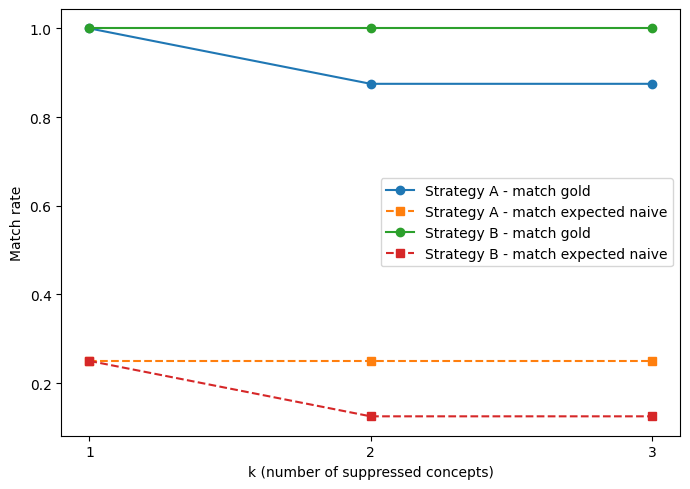

In [17]:
match_rate = merged_pilot.groupby(["strategy", "k"])[["match_gold", "match_expected"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
for strategy in ["A", "B"]:
    subset = match_rate[match_rate["strategy"] == strategy]
    ax.plot(subset["k"], subset["match_gold"], marker="o", label=f"Strategy {strategy} - match gold")
    ax.plot(subset["k"], subset["match_expected"], marker="s", linestyle="--", label=f"Strategy {strategy} - match expected naive")
ax.set_xlabel("k (number of suppressed concepts)")
ax.set_ylabel("Match rate")
ax.set_xticks([1, 2, 3])
ax.legend()
plt.tight_layout()
plt.show()



### 5.2 Knowledge Leakage

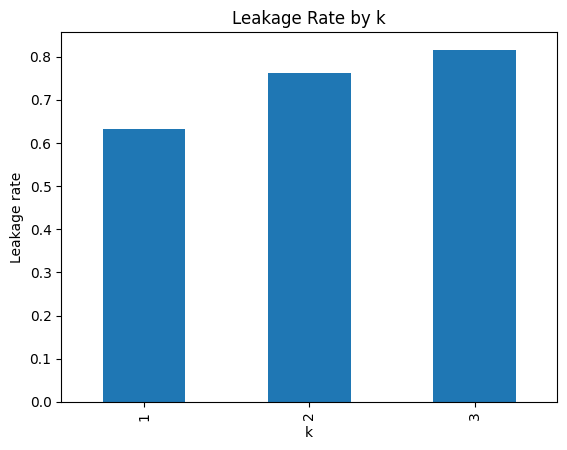

In [29]:
full_sim_df = pd.concat([
    simulated_pilot_df[simulated_pilot_df["strategy"] == chosen_strategy],
    simulated_scaled_df
], ignore_index=True)

concepts_lookup = (
    pd.concat([concepts_pilot_df, scaled_concepts_df], ignore_index=True)
    .drop_duplicates("question_id")
    .set_index("question_id")
)

def leaked_terms(concept_text, min_len=5):
    return [w.lower().strip(".,") for w in concept_text.split() if len(w) >= min_len]

def detect_leakage(row):
    concepts_row = concepts_lookup.loc[row["question_id"]]
    missing = get_missing_concepts(concepts_row, row["k"])
    reasoning_lower = row["reasoning"].lower()
    for concept in missing:
        terms = leaked_terms(concept)
        overlap = sum(1 for t in terms if t in reasoning_lower)
        if overlap >= 2:
            return True
    return False

full_sim_df["leaked"] = full_sim_df.apply(detect_leakage, axis=1)
full_sim_df = full_sim_df.merge(enriched_df[["id", "difficulty", "subject_area"]], left_on="question_id", right_on="id")

full_sim_df.groupby("k")["leaked"].mean().plot(kind="bar")
plt.ylabel("Leakage rate")
plt.title("Leakage Rate by k")
plt.show()

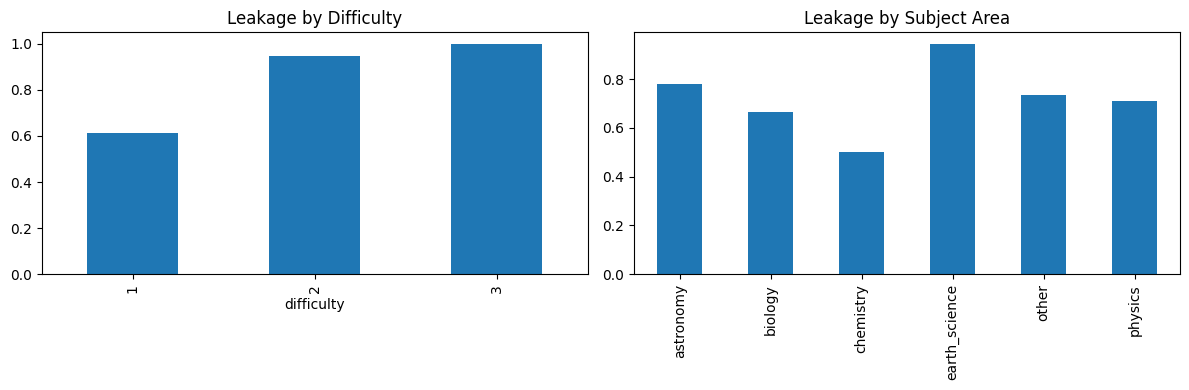

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
full_sim_df.groupby("difficulty")["leaked"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Leakage by Difficulty")
axes[0].set_xlabel("difficulty")
full_sim_df.groupby("subject_area")["leaked"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Leakage by Subject Area")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

In [31]:
leaked_examples = full_sim_df[full_sim_df["leaked"]].sample(3, random_state=1)
for _, row in leaked_examples.iterrows():
    concepts_row = concepts_lookup.loc[row["question_id"]]
    missing = get_missing_concepts(concepts_row, row["k"])
    print("question_id:", row["question_id"], "k:", row["k"])
    print("missing concept(s):", missing)
    print("reasoning:", row["reasoning"])
    print("---")

question_id: 13-461 k: 1
missing concept(s): ['Optical Lenses']
reasoning: The person knows that 'bad vision' usually refers to a lack of clarity or sight. They know that 'magnifying glass', 'binoculars', and 'telescope' are all tools used to enlarge images or bring distant objects closer, which typically aids people with limited sight or those who wanting to see things more clearly. They do not know about 'Optical Lenses' specifically (as a lens is the core component of these tools), but they know the general utility of these tools. They know that 'sungazing' is the seguinte process of looking directly at the sun, which is known to be dangerous and would likely damage the vision further rather than helping it. Therefore, sungazing is the least likely to help.
---
question_id: 7-24 k: 2
missing concept(s): ['Mechanical Waves', 'Vibration']
reasoning: The person is instructed to forget knowledge about 'Mechanical Waves' and 'Vibration'. However, they still know that sound travels throug

### 5.3 Failure Mode Classification

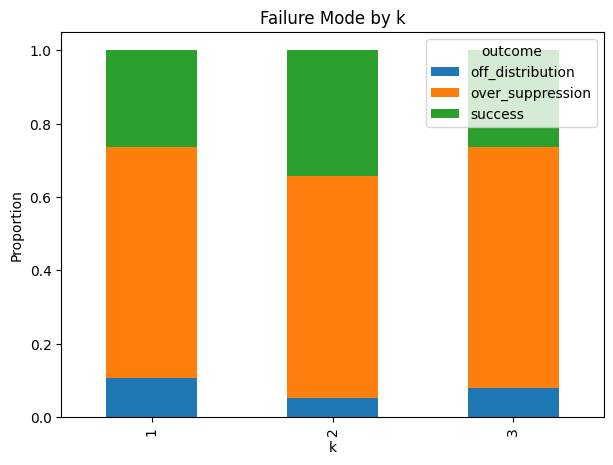

In [33]:
full_sim_df = full_sim_df.loc[:, ~full_sim_df.columns.duplicated()]
cols_to_drop = [c for c in ["expected_answer", "id", "answerKey", "gold_answer"] if c in full_sim_df.columns]
if cols_to_drop:
    full_sim_df = full_sim_df.drop(columns=cols_to_drop)
expected_lookup = pd.concat([expected_naive_pilot_df, expected_naive_scaled_df], ignore_index=True)
expected_lookup = expected_lookup.drop_duplicates(subset=["question_id", "k"]) 
full_sim_df = full_sim_df.merge(expected_lookup[["question_id", "k", "expected_answer"]], on=["question_id", "k"])
full_sim_df = full_sim_df.merge(enriched_df[["id", "answerKey"]], left_on="question_id", right_on="id")
full_sim_df = full_sim_df.rename(columns={"answerKey": "gold_answer"})

def classify_outcome(row):
    sim = str(row["simulated_answer"]).strip()
    exp = str(row["expected_answer"]).strip()
    gold = str(row["gold_answer"]).strip()
    if sim == exp:
        return "success"
    if sim == gold:
        return "over_suppression"
    return "off_distribution"

full_sim_df["outcome"] = full_sim_df.apply(classify_outcome, axis=1)
outcome_by_k = full_sim_df.groupby(["k", "outcome"]).size().unstack(fill_value=0)
outcome_by_k_pct = outcome_by_k.div(outcome_by_k.sum(axis=1), axis=0)
outcome_by_k_pct.plot(kind="bar", stacked=True, figsize=(7, 5))
plt.ylabel("Proportion")
plt.title("Failure Mode by k")
plt.show()

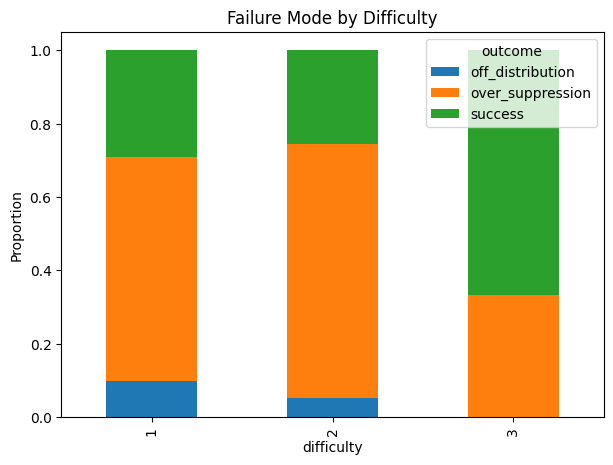

In [34]:
outcome_by_difficulty = full_sim_df.groupby(["difficulty", "outcome"]).size().unstack(fill_value=0)
outcome_by_difficulty_pct = outcome_by_difficulty.div(outcome_by_difficulty.sum(axis=1), axis=0)
outcome_by_difficulty_pct.plot(kind="bar", stacked=True, figsize=(7, 5))
plt.ylabel("Proportion")
plt.title("Failure Mode by Difficulty")
plt.show()

In [35]:
off_dist_examples = full_sim_df[full_sim_df["outcome"] == "off_distribution"].sample(2, random_state=1)
off_dist_examples[["question_id", "k", "simulated_answer", "expected_answer", "gold_answer", "reasoning"]]

,question_id,k,simulated_answer,expected_answer,gold_answer,reasoning
106,10-553,2,A,C,C,The person knows everything except volume and ...
70,1014,2,A,B,B,"The person knows about bears, raccoons, cats, ..."




## 6. Comparative Summary

### 6.1 Summary Table

In [36]:
def pilot_leak(row):
    concepts_row = concepts_lookup.loc[row["question_id"]]
    missing = get_missing_concepts(concepts_row, row["k"])
    reasoning_lower = row["reasoning"].lower()
    for concept in missing:
        terms = leaked_terms(concept)
        overlap = sum(1 for t in terms if t in reasoning_lower)
        if overlap >= 2:
            return True
    return False

summary_pilot = merged_pilot.copy()
summary_pilot["leaked"] = summary_pilot.apply(pilot_leak, axis=1)
summary_pilot["off_distribution"] = (~summary_pilot["match_gold"]) & (~summary_pilot["match_expected"])

summary_table = summary_pilot.groupby(["strategy", "k"]).agg(
    pct_match_gold=("match_gold", "mean"),
    pct_match_expected=("match_expected", "mean"),
    pct_leakage=("leaked", "mean"),
    pct_off_distribution=("off_distribution", "mean")
).reset_index()

summary_table

,strategy,k,pct_match_gold,pct_match_expected,pct_leakage,pct_off_distribution
0,A,1,1.000,0.250,0.250,0.0
1,A,2,0.875,0.250,0.375,0.0
2,A,3,0.875,0.250,0.375,0.0
3,B,1,1.000,0.250,0.750,0.0
4,B,2,1.000,0.125,0.875,0.0
5,B,3,1.000,0.125,1.000,0.0


### 6.2 Confidence Calibration

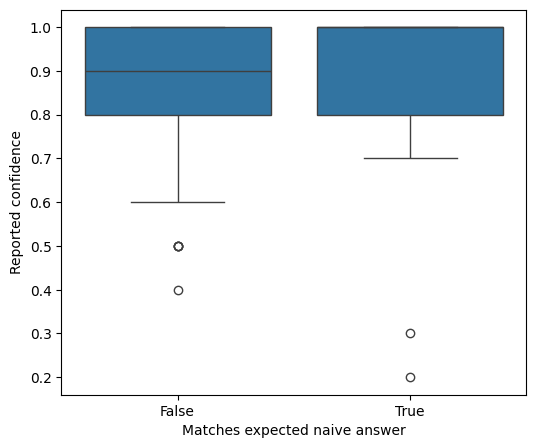

match_expected
False    0.855556
True     0.872727
Name: confidence, dtype: float64

In [37]:
full_sim_df["match_expected"] = full_sim_df["simulated_answer"] == full_sim_df["expected_answer"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=full_sim_df, x="match_expected", y="confidence", ax=ax)
ax.set_xlabel("Matches expected naive answer")
ax.set_ylabel("Reported confidence")
plt.show()

full_sim_df.groupby("match_expected")["confidence"].mean()